# Padrão-ouro — EDA e preparação para Regressão Linear
### Dataset: `housing_sp_city.csv` — apartamentos à venda em São Paulo

Este notebook é um **modelo de referência**. Ele mostra a ordem que a maioria dos
data scientists segue **antes** de treinar um modelo, e *por quê* cada passo existe.

**Mapa do notebook**

| # | Etapa | O que se decide aqui |
|---|-------|----------------------|
| 1 | Setup | bibliotecas |
| 2 | Carga + encoding | ler o arquivo, consertar acentuação |
| 3 | Primeiro contato | tamanho, tipos, granularidade, duplicatas |
| 4 | Escopo | qual população o modelo representa |
| 5 | Limpeza estrutural | erros objetivos (colunas inúteis, tipo errado) |
| 6 | EDA do alvo | distribuição de `preco_venda`, decidir transformação |
| 7 | EDA univariada | uma variável de cada vez: histograma + boxplot |
| 8 | Classificar problemas | impossível × faltante × extremo (são coisas diferentes!) |
| 9 | EDA de faltantes | quanto falta, e o que a ausência significa |
| 10 | Limpeza pós-EDA | **uma** célula idempotente, só remove o impossível (preserva `NaN`) |
| 11 | Feature engineering | transformações determinísticas (seguras antes do split) |
| 12 | EDA bivariada | relação de cada feature com o alvo + multicolinearidade (`r`, VIF) |
| 13 | EDA da categórica | `bairro`: cardinalidade e efeito no preço |
| 14 | Split treino/teste | 80/20 estratificado |
| 15 | Pré-processamento sem *leakage* | `Pipeline` + `ColumnTransformer`, `fit` só no treino |
| 16 | Baseline | regressão linear + validação cruzada |
| 17 | Acertou ou errou? | real × previsto imóvel a imóvel; `R²`, *baseline*, *overfitting* sem jargão |
| 18 | Interpretar coeficientes | `statsmodels` OLS: `p-valor` e efeito de cada variável (§9 da nota) |
| 19 | Resumo | os princípios em uma tela |

---

### A regra que organiza tudo: *data leakage*

Antes do split só pode entrar o que **não aprende nada a partir dos dados**:

| Pode ser feito antes do split | Só depois do split (ajustar só no treino) |
|---|---|
| Ler e corrigir encoding | Preencher faltante com média/mediana/moda |
| Filtrar a população (escopo) | Padronização / normalização (scaler) |
| Remover colunas inúteis | Encoding por estatística (target/frequency encoding) |
| Corrigir tipo de dado | Selecionar features por correlação com o alvo |
| Remover linhas **fisicamente impossíveis** | Cortar *outliers* por quantil dos dados |
| `log`, razões, extrair ano de data (linha a linha) | PCA, seleção de features, binning por quantil |

Se você "aprende" algo usando as linhas de teste, sua avaliação fica otimista e mente
sobre o desempenho real.

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42   # fixa a aleatoriedade -> resultados reproduziveis

## 2. Carga dos dados + correção de encoding

O arquivo foi salvo com a acentuação corrompida (*mojibake*): os bytes de UTF-8
foram gravados como se fossem Latin-1. Lemos como Latin-1 (não dá erro) e
desfazemos a corrupção coluna a coluna.

> Se o seu arquivo abre limpo com `pd.read_csv(path)` (UTF-8, o padrão), pule a
> função `corrigir_mojibake` — ela só existe por causa deste dataset específico.

In [2]:
CAMINHO = os.path.join(os.getcwd(), "housing_sp_city.csv")

df_raw = pd.read_csv(CAMINHO, sep=",", encoding="latin1")
print("Formato do arquivo bruto:", df_raw.shape)

Formato do arquivo bruto: (133964, 18)


In [3]:
def corrigir_mojibake(valor):
    # desfaz "UTF-8 lido como Latin-1": re-encoda em latin1 e decodifica em utf-8
    if isinstance(valor, str):
        try:
            return valor.encode("latin1").decode("utf-8")
        except UnicodeDecodeError:
            return valor          # string ja estava correta
    return valor

df = df_raw.copy()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].map(corrigir_mojibake)

df.head()

,logradouro,numero,bairro,cep,cidade,tipo_imovel,area_util,banheiros,suites,quartos,vagas_garagem,anuncio_criado,tipo_anuncio,preco_venda,taxa_condominio,periodicidade,preco_aluguel,iptu_ano
0,Rua Juvenal Galeno,53,Jardim da Saúde,4290030.0,São Paulo,Casa de dois andares,388.0,3.0,1.0,4.0,6.0,2017-02-07,Venda,700000,NaN,NaN,NaN,NaN
1,Rua Juruaba,16,Vila Santa Teresa (Zona Sul),4187320.0,São Paulo,Casa,129.0,2.0,1.0,3.0,2.0,2016-03-21,Venda,336000,NaN,NaN,NaN,NaN
2,Avenida Paulista,402,Bela Vista,1311000.0,São Paulo,Comercial,396.0,4.0,0.0,0.0,5.0,2018-12-18,Locação,24929,4900.0,MONTHLY,29829.0,4040.0
3,Rua Alvorada,1190,Vila Olímpia,4550004.0,São Paulo,Apartamento,80.0,2.0,1.0,3.0,2.0,2018-10-26,Venda,739643,686.0,NaN,NaN,1610.0
4,Rua Curitiba,380,Paraíso,4005030.0,São Paulo,Apartamento,3322.0,5.0,4.0,4.0,5.0,2018-12-14,Venda,7520099,6230.0,NaN,NaN,18900.0


## 3. Primeiro contato com os dados

Perguntas desta seção (as mesmas em **qualquer** projeto):

1. **Quantas linhas e colunas?**
2. **O que é uma linha?** (a *granularidade*) — aqui: 1 anúncio de imóvel.
3. **Que tipo tem cada coluna?** número, texto, data (datas quase sempre chegam como texto).
4. **Tem linha duplicada?**
5. **Qual a cara e a escala de cada coluna?** (`describe`)

In [4]:
print("linhas x colunas:", df.shape)
print()
df.info()

linhas x colunas: (133964, 18)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133964 entries, 0 to 133963
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   logradouro       126962 non-null  object 
 1   numero           89823 non-null   object 
 2   bairro           133943 non-null  object 
 3   cep              128056 non-null  float64
 4   cidade           133964 non-null  object 
 5   tipo_imovel      133964 non-null  object 
 6   area_util        130868 non-null  float64
 7   banheiros        133051 non-null  float64
 8   suites           120347 non-null  float64
 9   quartos          130945 non-null  float64
 10  vagas_garagem    129539 non-null  float64
 11  anuncio_criado   133964 non-null  object 
 12  tipo_anuncio     133964 non-null  object 
 13  preco_venda      133964 non-null  int64  
 14  taxa_condominio  117127 non-null  float64
 15  periodicidade    29051 non-null   object 
 16  preco_

In [5]:
# describe em TUDO (numéricas e categóricas) — visão geral de escala e cardinalidade
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
logradouro,126962,13017,Rua Bela Cintra,834,NaN,NaN,NaN,NaN,NaN,NaN,NaN
numero,89823,3356,1,1261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bairro,133943,1780,Jardim Paulista,4284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cep,128056.0,NaN,NaN,NaN,3550899.327083,2177018.669038,0.0,2312135.0,3413030.0,4576050.0,99810303.0
cidade,133964,174,São Paulo,133456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_imovel,133964,18,Apartamento,72241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_util,130868.0,NaN,NaN,NaN,224.430655,5764.344658,1.0,62.0,108.0,200.0,2025000.0
banheiros,133051.0,NaN,NaN,NaN,2.375683,2.146044,0.0,1.0,2.0,3.0,200.0
suites,120347.0,NaN,NaN,NaN,1.106534,1.218938,0.0,0.0,1.0,2.0,80.0
quartos,130945.0,NaN,NaN,NaN,2.327023,2.140123,0.0,2.0,2.0,3.0,600.0


In [6]:
# Duplicatas: linhas 100% idênticas em todas as colunas.
# Sem um ID único confiável, o mais seguro é assumir "mesmo anúncio repetido" e remover.
n_dup = df.duplicated().sum()
print(f"linhas duplicadas: {n_dup}  ({n_dup/len(df):.1%})")

linhas duplicadas: 1271  (0.9%)


## 4. Definir o escopo do estudo

Filtramos para **`tipo_imovel == 'Apartamento'`** e **`tipo_anuncio == 'Venda'`**.

Por quê: o preço de uma casa, de um terreno, de uma sala comercial e de um aluguel
seguem lógicas diferentes. Um único modelo de regressão não dá conta de tudo isso ao
mesmo tempo. Escolhemos **um mercado** e o modelo passa a representar só ele.

> Esse filtro define a população. Faça-o **antes** do split — o split tem que
> sortear linhas do universo que você realmente quer modelar.

In [7]:
df_ap = df[(df["tipo_imovel"] == "Apartamento") & (df["tipo_anuncio"] == "Venda")].copy()
print("apartamentos à venda:", df_ap.shape)

apartamentos à venda: (64146, 18)


## 5. Limpeza estrutural (só erros objetivos)

Aqui entram **apenas** coisas factualmente erradas ou inúteis — nada que dependa de
"olhar a distribuição". Pode ser feito na base inteira, sem risco de *leakage*:

- remover as duplicatas
- remover colunas que não ajudam **neste** recorte
- corrigir o tipo de `anuncio_criado` (texto → data) e extrair o ano

In [8]:
df_ap = df_ap.drop_duplicates().copy()

# --- por que cada coluna sai ---------------------------------------------------
# cidade         : ~99% é "São Paulo" (constante) e o resto são bairros no campo errado
# periodicidade,
# preco_aluguel  : são de LOCAÇÃO; filtramos só VENDA -> sempre vazias/irrelevantes
# cep, logradouro,
# numero         : identificação fina de endereço; alta cardinalidade, pouco uso num 1º modelo
#                  (mantemos 'bairro' de propósito: localização é o fator nº 1 de preço)
# tipo_imovel,
# tipo_anuncio   : viraram constantes depois do filtro da seção 4
colunas_remover = [
    "cidade", "periodicidade", "preco_aluguel",
    "cep", "logradouro", "numero",
    "tipo_imovel", "tipo_anuncio",
]
df_ap = df_ap.drop(columns=colunas_remover)

In [9]:
# 'anuncio_criado' vinha como texto -> datetime dá acesso a .dt.year etc.
df_ap["anuncio_criado"] = pd.to_datetime(df_ap["anuncio_criado"], errors="coerce")

# O ano de uma linha depende só dela mesma -> feature determinística, sem leakage.
# O dia exato dificilmente explica preço; guardamos só o ano.
df_ap["ano_anuncio"] = df_ap["anuncio_criado"].dt.year
df_ap = df_ap.drop(columns=["anuncio_criado"])

df_ap.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63671 entries, 3 to 133961
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bairro           63661 non-null  object 
 1   area_util        63283 non-null  float64
 2   banheiros        63670 non-null  float64
 3   suites           58049 non-null  float64
 4   quartos          63671 non-null  float64
 5   vagas_garagem    62551 non-null  float64
 6   preco_venda      63671 non-null  int64  
 7   taxa_condominio  60058 non-null  float64
 8   iptu_ano         54129 non-null  float64
 9   ano_anuncio      63671 non-null  int32  
dtypes: float64(7), int32(1), int64(1), object(1)
memory usage: 5.1+ MB


## 6. EDA do alvo — `preco_venda`

**Sempre comece pelo alvo.** Ele decide o tipo de problema, a métrica e se você
precisa transformar algo.

O que olhar:

- **Forma da distribuição** (histograma). Preço de imóvel é quase sempre
  *assimétrico à direita*: muitos imóveis baratos, poucos caríssimos.
- **`skew` (assimetria)**: 0 = simétrica; `>1` = cauda forte à direita; `>2` já é bem torta.
- **`kurt` (curtose)**: peso das caudas / presença de *outliers* (0 ≈ normal, no pandas).
- **média vs mediana**: média muito acima da mediana confirma a cauda.

**O que se faz quando o `skew` é alto:** transformar o alvo com `log`. A regressão
linear assume que o *erro* é aproximadamente normal e simétrico; com o alvo em
`log1p`, a distribuição fica quase normal e o modelo para de ser dominado pelos
imóveis de luxo. Na hora de prever, volta para reais com `expm1`.

In [10]:
alvo = df_ap["preco_venda"]

resumo = pd.DataFrame({
    "Métrica": ["contagem", "média", "mediana", "desvio-padrão", "mínimo",
                "1º quartil", "3º quartil", "máximo", "assimetria (skew)", "curtose (kurt)"],
    "Valor":   [f"{alvo.count():,.0f}",
                f"R$ {alvo.mean():,.0f}", f"R$ {alvo.median():,.0f}", f"R$ {alvo.std():,.0f}",
                f"R$ {alvo.min():,.0f}", f"R$ {alvo.quantile(.25):,.0f}",
                f"R$ {alvo.quantile(.75):,.0f}", f"R$ {alvo.max():,.0f}",
                f"{alvo.skew():.2f}", f"{alvo.kurt():.2f}"],
})
resumo

,Métrica,Valor
0,contagem,"63,671"
1,média,"R$ 762,449"
2,mediana,"R$ 461,999"
3,desvio-padrão,"R$ 1,047,356"
4,mínimo,"R$ 10,500"
5,1º quartil,"R$ 273,000"
6,3º quartil,"R$ 854,000"
7,máximo,"R$ 74,200,000"
8,assimetria (skew),11.12
9,curtose (kurt),440.95


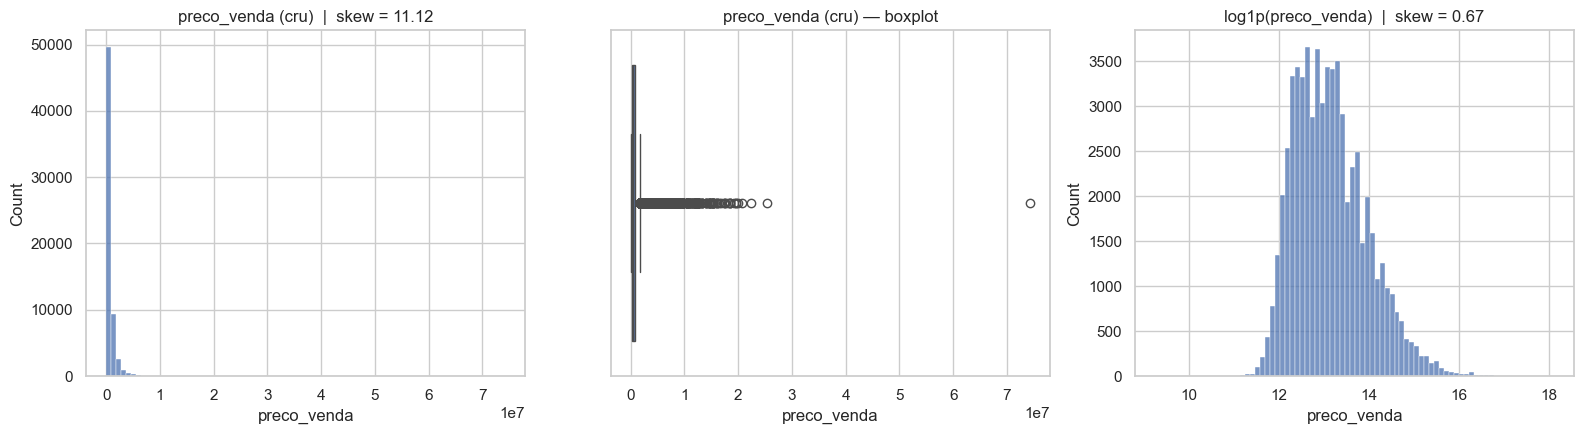

In [11]:
alvo_log = np.log1p(alvo)          # log1p(x) = log(1 + x): seguro se houver zeros

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(alvo, bins=80, ax=axes[0])
axes[0].set_title(f"preco_venda (cru)  |  skew = {alvo.skew():.2f}")

sns.boxplot(x=alvo, ax=axes[1])
axes[1].set_title("preco_venda (cru) — boxplot")

sns.histplot(alvo_log, bins=80, ax=axes[2])
axes[2].set_title(f"log1p(preco_venda)  |  skew = {alvo_log.skew():.2f}")

plt.tight_layout(); plt.show()

**Leitura esperada:** o histograma cru fica "espremido" à esquerda com uma cauda
longa (`skew` bem acima de 1); o `log1p` fica quase simétrico (`skew` perto de 0).
→ **decisão: treinar o modelo em `log1p(preco_venda)`.**

`log` é determinístico (não aprende parâmetro), então tanto faz aplicar antes ou
depois do split. Aqui aplicamos na hora do modelo (seção 14).

## 7. EDA univariada das features numéricas

Uma variável de cada vez. Para cada numérica: **histograma** (forma) + **boxplot**
(escala e pontos extremos). O objetivo é *conhecer* cada coluna e anotar o que
parece errado — sem mexer em nada ainda.

In [12]:
num_cols = ["area_util", "banheiros", "suites", "quartos",
            "vagas_garagem", "taxa_condominio", "iptu_ano", "ano_anuncio"]

df_ap[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
area_util,63283.0,117.048623,636.096550,1.0,60.0,82.0,136.0,129000.0
banheiros,63670.0,2.261787,1.664083,0.0,1.0,2.0,3.0,99.0
suites,58049.0,1.171614,1.132565,0.0,0.0,1.0,1.0,23.0
quartos,63671.0,2.577626,0.846394,0.0,2.0,3.0,3.0,30.0
vagas_garagem,62551.0,1.750811,1.518955,0.0,1.0,1.0,2.0,215.0
taxa_condominio,60058.0,2030.221536,107910.443336,0.0,280.0,482.0,884.0,24430000.0
iptu_ano,54129.0,938.980916,57209.505766,0.0,0.0,71.0,301.0,10367000.0
ano_anuncio,63671.0,2017.775895,0.957173,2011.0,2017.0,2018.0,2018.0,2019.0


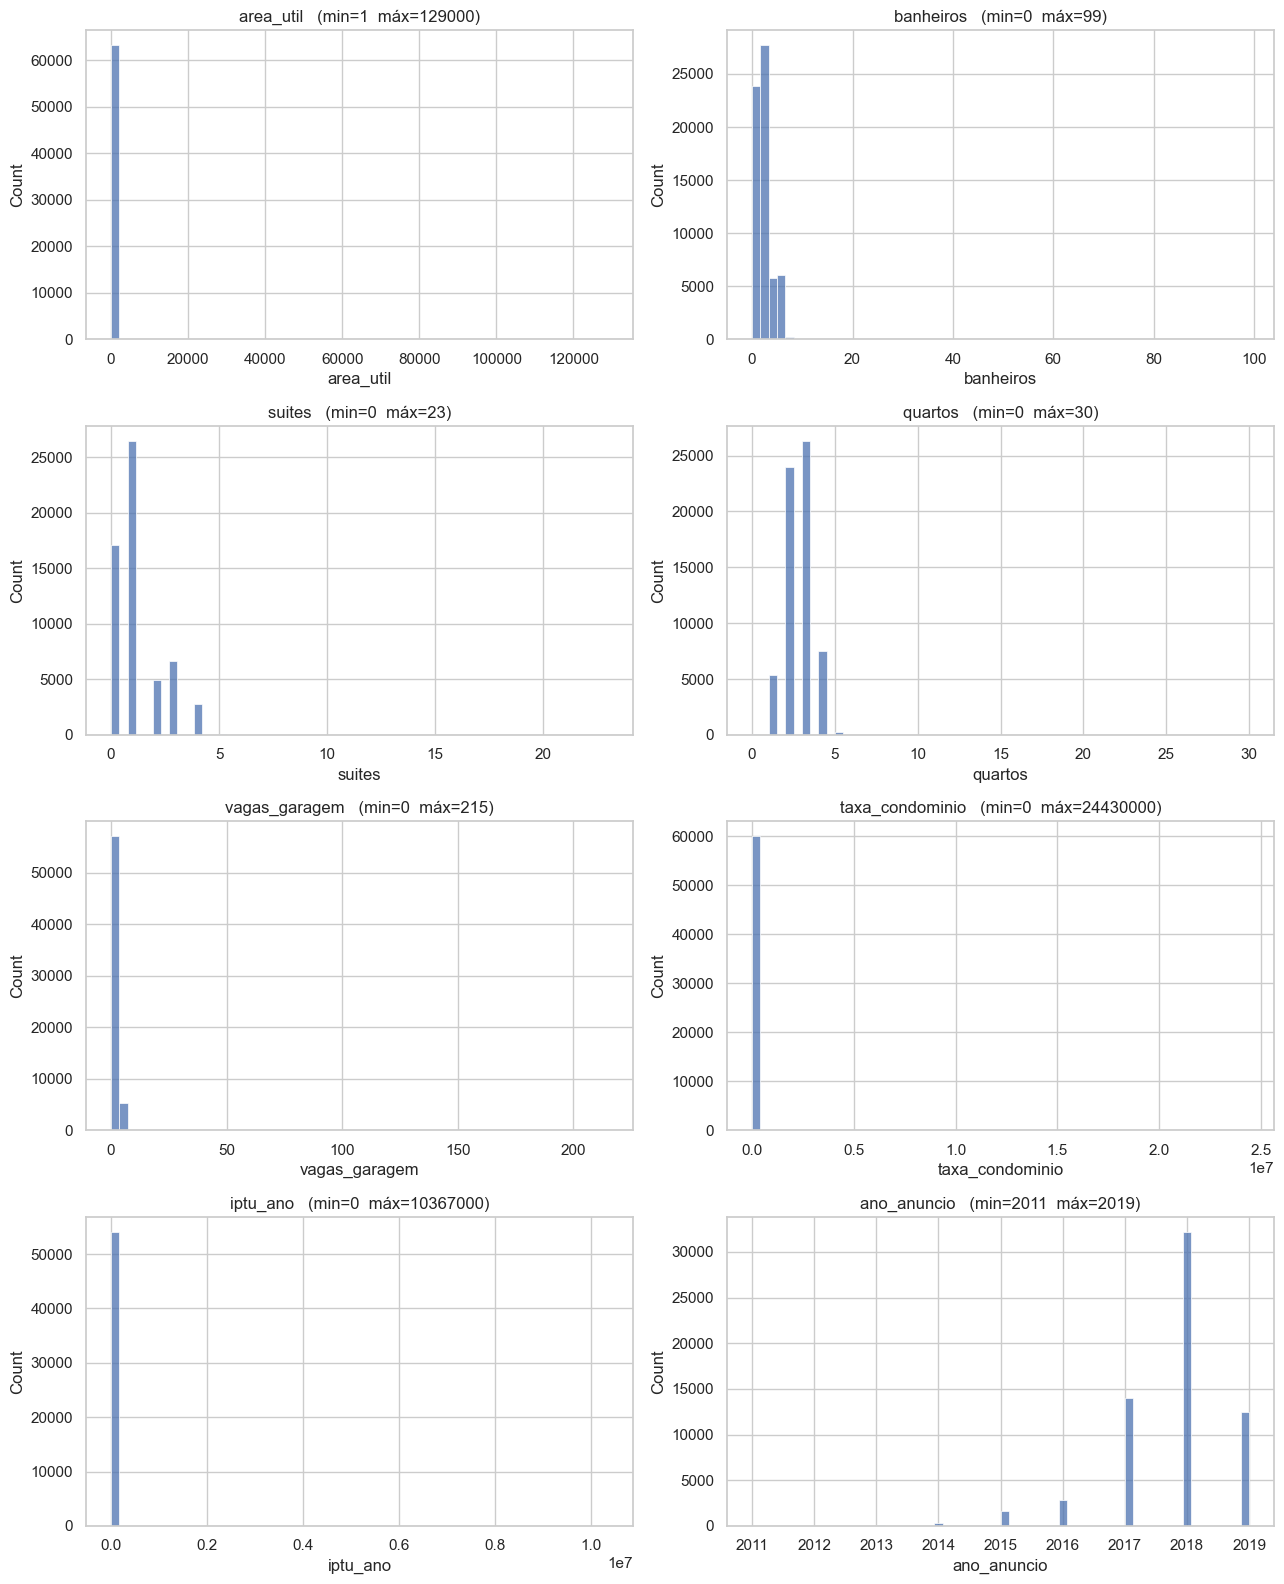

In [13]:
fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df_ap[col].dropna(), bins=60, ax=ax)
    ax.set_title(f"{col}   (min={df_ap[col].min():.0f}  máx={df_ap[col].max():.0f})")
plt.tight_layout(); plt.show()

Vários histogramas vão parecer "uma barra só": é o efeito de **um valor absurdo**
esticando o eixo (ex.: `area_util` até 129.000 m²). Isso já é o diagnóstico da
próxima seção.

## 8. Classificar os problemas: impossível × faltante × extremo

Três coisas **diferentes**, com tratamentos diferentes:

| Tipo | Definição | O que fazer | Quando |
|------|-----------|-------------|--------|
| **Impossível** | não pode ser verdade no mundo real (área de 129.000 m², 99 banheiros, condomínio de R$ 24 mi) | remover a linha (ou corrigir, se souber o valor certo) | **antes** do split — é lixo em qualquer cenário |
| **Faltante (`NaN`)** | o dado não foi informado | decidir o *significado*; preencher **na pipeline**, ajustando só no treino | valor entra **depois** do split |
| **Extremo porém real** | uma cobertura de R$ 15 mi existe de verdade | é decisão de modelagem; se for aparar, aparar **só o treino** | **depois** do split |

### ⚠️ A armadilha nº 1 do iniciante

`df[df["suites"] <= df["quartos"]]` **também remove todas as linhas onde `suites`
é `NaN`**, porque `NaN <= x` resulta em `False`. Você acha que está tirando erro e
está, na verdade, jogando fora dado faltante.

**Padrão seguro:** sempre proteja o `NaN` explicitamente.

In [14]:
# Quantas linhas cada regra de "impossível" remove — SEM apagar NaN sem querer.
# .between(a, b) devolve False para NaN; o "| .isna()" preserva os faltantes.
def conta_fora(serie, lo, hi):
    dentro = serie.between(lo, hi) | serie.isna()
    return (~dentro).sum()

regras = {
    "area_util fora de [20, 500]":       conta_fora(df_ap["area_util"], 20, 500),
    "banheiros fora de [1, 10]":         conta_fora(df_ap["banheiros"], 1, 10),
    "quartos fora de [1, 12]":           conta_fora(df_ap["quartos"], 1, 12),
    "suites fora de [0, 10]":            conta_fora(df_ap["suites"], 0, 10),
    "vagas_garagem fora de [0, 20]":     conta_fora(df_ap["vagas_garagem"], 0, 20),
    "preco_venda fora de [50k, 30M]":    conta_fora(df_ap["preco_venda"], 50_000, 30_000_000),
    "taxa_condominio > 50k":             (df_ap["taxa_condominio"] > 50_000).sum(),
    "iptu_ano > 500k":                   (df_ap["iptu_ano"] > 500_000).sum(),
    "suites > quartos (ambos preench.)": ((df_ap["suites"] > df_ap["quartos"])
                                          & df_ap[["suites", "quartos"]].notna().all(axis=1)).sum(),
}
pd.Series(regras, name="linhas_afetadas").sort_values(ascending=False)

banheiros fora de [1, 10]            2066
area_util fora de [20, 500]           400
quartos fora de [1, 12]               119
suites > quartos (ambos preench.)      72
taxa_condominio > 50k                  65
vagas_garagem fora de [0, 20]           5
iptu_ano > 500k                         5
preco_venda fora de [50k, 30M]          4
suites fora de [0, 10]                  2
Name: linhas_afetadas, dtype: int64

In [15]:
# Espiar ALGUNS registros impossíveis antes de decidir (inspeção != remoção;
# célula separada, só exibe, não altera df_ap)
cols_espiar = ["bairro", "area_util", "banheiros", "suites", "quartos",
               "vagas_garagem", "preco_venda", "taxa_condominio"]
df_ap.loc[(df_ap["area_util"] > 500) | (df_ap["banheiros"] > 10)
          | (df_ap["vagas_garagem"] > 20), cols_espiar].head(15)

,bairro,area_util,banheiros,suites,quartos,vagas_garagem,preco_venda,taxa_condominio
4,Paraíso,3322.0,5.0,4.0,4.0,5.0,7520099,6230.0
488,Paraíso do Morumbi,715.0,7.0,5.0,7.0,9.0,4094999,5950.0
605,Paraíso,632.0,5.0,4.0,4.0,7.0,11899993,0.0
913,Parque Savoy City,800.0,0.0,0.0,2.0,8.0,1050000,0.0
940,Paraíso do Morumbi,607.0,0.0,4.0,4.0,6.0,4452000,3511.0
1092,Vila Nova Conceição,530.0,5.0,4.0,4.0,6.0,9730000,NaN
2078,Cidade Jardim,754.0,5.0,4.0,4.0,5.0,12243000,7531.0
4639,Paraíso,608.0,5.0,4.0,0.0,7.0,11921000,0.0
5148,Higienópolis,178.0,99.0,1.0,2.0,0.0,1050000,644.0
5447,Alto de Pinheiros,516.0,4.0,3.0,3.0,4.0,5148619,0.0


## 9. EDA dos valores faltantes

Duas perguntas:

1. **Quanto falta** em cada coluna (absoluto e %).
2. **O que a ausência significa?** Nem todo `NaN` é igual — e isso muda como você
   preenche:

| Coluna | `NaN` provavelmente é… | Estratégia sugerida |
|--------|----------------------|---------------------|
| `suites` | "0 suítes" | preencher com 0 |
| `vagas_garagem` | "0 vagas" | preencher com 0 |
| `taxa_condominio` | "não informado" (e muitos `0` também são) | flag `sem_info` + imputar mediana no treino |
| `iptu_ano` | "não informado" (idem: muitos `0`) | flag `sem_info` + imputar mediana no treino |
| `area_util` | dado essencial ausente | poucas linhas → pode remover, ou imputar mediana |
| `bairro` | desconhecido | pouquíssimas → categoria `"Desconhecido"` |

> O *valor* que preenche (`mediana`, `moda`…) é calculado **no treino** e aplicado
> ao teste. É por isso que a imputação vai para dentro da `Pipeline` (seção 15),
> não aqui.

In [16]:
na = pd.DataFrame({
    "faltantes": df_ap.isna().sum(),
    "pct":       (df_ap.isna().mean() * 100).round(1),
    "zeros":     (df_ap == 0).sum(),           # zeros suspeitos convivem com os NaN
}).sort_values("faltantes", ascending=False)
na

,faltantes,pct,zeros
iptu_ano,9542,15.0,19889
suites,5622,8.8,17091
taxa_condominio,3613,5.7,6788
vagas_garagem,1120,1.8,3225
area_util,388,0.6,0
bairro,10,0.0,0
banheiros,1,0.0,2049
quartos,0,0.0,116
preco_venda,0,0.0,0
ano_anuncio,0,0.0,0


In [17]:
# A ausência tem padrão? (imóvel sem taxa_condominio tende a ser mais barato?)
tem_cond = df_ap["taxa_condominio"].notna() & df_ap["taxa_condominio"].gt(0)
print("preço mediano COM taxa_condominio informada:",
      f'R$ {df_ap.loc[tem_cond, "preco_venda"].median():,.0f}')
print("preço mediano SEM taxa_condominio informada:",
      f'R$ {df_ap.loc[~tem_cond, "preco_venda"].median():,.0f}')

preço mediano COM taxa_condominio informada: R$ 468,999
preço mediano SEM taxa_condominio informada: R$ 451,500


## 10. Limpeza pós-EDA — **uma** célula, idempotente

Fazemos a limpeza **antes** da EDA de relações (seções 12–13) de propósito: uma
única linha impossível (área de 129.000 m²) sozinha destrói uma correlação ou um
`scatter`. Só dá para confiar nesses gráficos depois de tirar o lixo.

Boas práticas aplicadas aqui:

- **Uma única célula** faz toda a remoção de linhas, sempre partindo de `df_ap`.
  Assim você pode reexecutá-la quantas vezes quiser sem "filtrar o filtrado".
- Só removemos o **impossível**. `NaN` é **preservado** (vai para a pipeline).
- **Extremos reais** (preço muito alto, mas plausível) **não** são cortados aqui —
  se quiser cortá-los, é depois do split e só no treino.
- Guardamos `df_ap` intacto e trabalhamos numa cópia `dados`.

In [18]:
def dentro(serie, lo, hi):
    # True se lo <= x <= hi  OU  x é NaN  (assim os faltantes NÃO são removidos)
    return serie.between(lo, hi) | serie.isna()

mask_ok = (
      dentro(df_ap["area_util"],       20,  500)   # 99,5% dos apês têm <= 519 m²; acima disso é implausível
    & dentro(df_ap["banheiros"],        1,   10)
    & dentro(df_ap["quartos"],          1,   12)
    & dentro(df_ap["suites"],           0,   10)
    & dentro(df_ap["vagas_garagem"],    0,   20)
    & dentro(df_ap["taxa_condominio"],  0,   50_000)
    & dentro(df_ap["iptu_ano"],         0,   500_000)
    & df_ap["preco_venda"].between(50_000, 30_000_000)   # alvo não pode ser NaN
)
# regra relacional: só derruba quando os DOIS campos existem e a relação é violada
viola = (df_ap["suites"] > df_ap["quartos"]) & df_ap[["suites", "quartos"]].notna().all(axis=1)

dados = df_ap[mask_ok & ~viola].copy()

print(f"linhas: {len(df_ap):,}  ->  {len(dados):,}   "
      f"({1 - len(dados)/len(df_ap):.1%} removido — só o impossível)")
print("\nfaltantes preservados:")
print(dados.isna().sum()[lambda s: s > 0].sort_values(ascending=False))

linhas: 63,671  ->  61,062   (4.1% removido — só o impossível)

faltantes preservados:
iptu_ano           9468
suites             5587
taxa_condominio    3566
vagas_garagem      1043
area_util           308
bairro               10
banheiros             1
dtype: int64


## 11. Feature engineering determinística

Transformações que dependem **só da própria linha** — seguras antes do split:

- **flags de "não informado"** para `taxa_condominio` e `iptu_ano` (onde é `0` ou
  `NaN`). A flag preserva a informação "esse dado faltava" mesmo depois de imputar.
- converter esses `0` "falsos" em `NaN`, para a imputação da pipeline cuidar deles.

> `preco_por_m2` seria uma feature forte, mas ela carrega o próprio preço na
> definição — num exercício de regressão linear "pura" isso confunde a leitura dos
> coeficientes. Fica como ideia para depois.

In [19]:
for col in ["taxa_condominio", "iptu_ano"]:
    dados[f"{col}_sem_info"] = (dados[col].isna() | dados[col].eq(0)).astype(int)
    dados[col] = dados[col].replace(0, np.nan)      # 0 "falso" -> NaN (imputa depois)

dados[["taxa_condominio", "taxa_condominio_sem_info",
       "iptu_ano", "iptu_ano_sem_info"]].head()

,taxa_condominio,taxa_condominio_sem_info,iptu_ano,iptu_ano_sem_info
3,686.0,0,1610.0,0
6,1120.0,0,489.0,0
9,NaN,1,NaN,1
13,339.0,0,819.0,0
15,322.0,0,NaN,1


## 12. EDA bivariada — feature × alvo (na base já limpa)

Agora as relações, sobre `dados` (sem os valores impossíveis). Duas ferramentas:

- **`scatter` de cada feature numérica contra `preco_venda`**: a relação é linear?
  tem formato de funil? tem patamar?
- **matriz de correlação** (`corr`): força da relação linear de cada feature com o
  alvo **e entre as features** (multicolinearidade).

### Como ler um valor de correlação `r`

`r` vai de −1 a +1. O **sinal** diz a direção; o **módulo** (`|r|`) diz a força.
Convenção comum (não é lei — são faixas de bom senso):

| `\|r\|` | leitura |
|---|---|
| < 0,3 | fraca — ignore |
| 0,3 – 0,5 | moderada |
| 0,5 – 0,7 | forte |
| **0,7 – 0,9** | **muito forte** — acende o alerta de multicolinearidade |
| > 0,9 | quase a mesma variável (redundante) |

**Multicolinearidade** = duas (ou mais) *features* muito correlacionadas **entre si**.
Não atrapalha a *previsão*, mas deixa os **coeficientes** instáveis e sem
interpretação confiável (foi o que fez `quartos` sair negativo na seção 18).

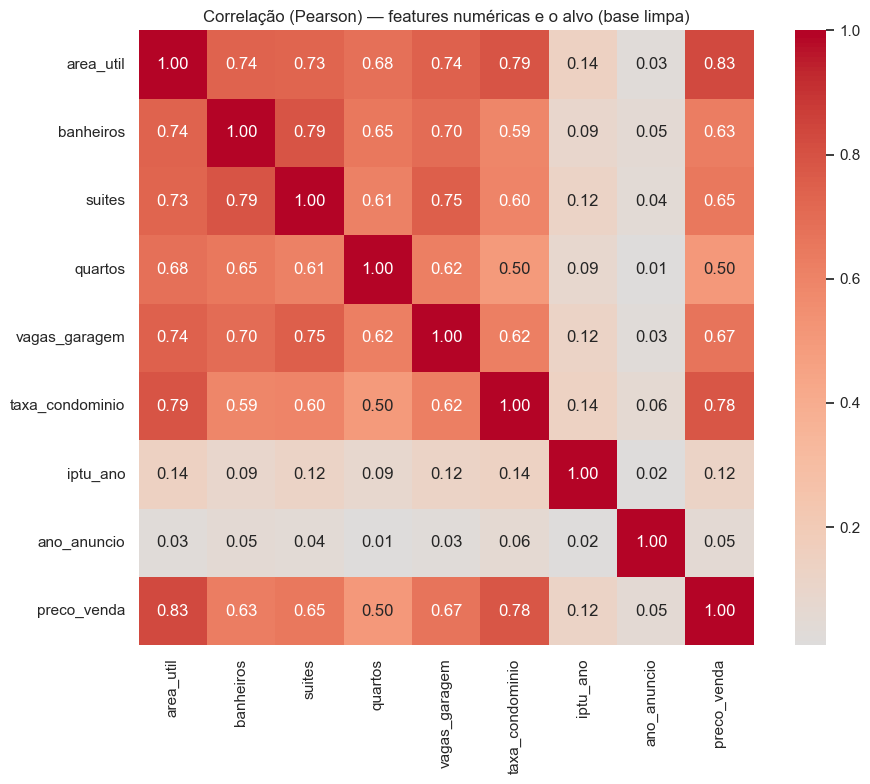

Correlação com preco_venda (ordenada):
area_util          0.832
taxa_condominio    0.784
vagas_garagem      0.666
suites             0.651
banheiros          0.630
quartos            0.503
iptu_ano           0.123
ano_anuncio        0.053
Name: preco_venda, dtype: float64


In [20]:
corr = dados[num_cols + ["preco_venda"]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlação (Pearson) — features numéricas e o alvo (base limpa)")
plt.tight_layout(); plt.show()

print("Correlação com preco_venda (ordenada):")
print(corr["preco_venda"].drop("preco_venda").sort_values(ascending=False).round(3))

In [21]:
# --- É AQUI que se conclui "essas features andam juntas" ---
# 1) todos os pares de features (sem o alvo), ordenados pelo |r|
cf = dados[num_cols].corr()
pares = (cf.where(~np.eye(len(cf), dtype=bool))   # tira a diagonal (r=1 consigo mesmo)
           .stack().rename("r").reset_index())
pares = pares[pares["level_0"] < pares["level_1"]]           # cada par uma vez só
pares = pares.reindex(pares["r"].abs().sort_values(ascending=False).index)
print("Pares de features com |r| >= 0.6 (alerta de multicolinearidade):")
print(pares[pares["r"].abs() >= 0.6].to_string(index=False))

Pares de features com |r| >= 0.6 (alerta de multicolinearidade):
        level_0         level_1        r
      banheiros          suites 0.792914
      area_util taxa_condominio 0.789548
         suites   vagas_garagem 0.753373
      area_util   vagas_garagem 0.741999
      area_util       banheiros 0.738057
      area_util          suites 0.729458
      banheiros   vagas_garagem 0.700983
      area_util         quartos 0.683089
      banheiros         quartos 0.654464
taxa_condominio   vagas_garagem 0.618676
        quartos   vagas_garagem 0.617658
        quartos          suites 0.611338


In [22]:
# 2) VIF — o teste mais rigoroso. Pergunta: "quão bem TODAS as outras features
#    juntas conseguem prever ESTA feature?" (o par a par não pega isso).
#    Regra de bolso:  VIF ~1 = ótimo | 1–5 = ok | 5–10 = preocupante | >10 = grave.
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

Xvif = sm.add_constant(dados[num_cols].fillna(dados[num_cols].median()))
vif = pd.DataFrame({
    "feature": Xvif.columns,
    "VIF": [variance_inflation_factor(Xvif.values, i) for i in range(Xvif.shape[1])],
})
print(vif[vif["feature"] != "const"].round(2).to_string(index=False))

        feature  VIF
      area_util 4.20
      banheiros 3.24
         suites 3.20
        quartos 2.12
  vagas_garagem 2.89
taxa_condominio 2.06
       iptu_ano 1.02
    ano_anuncio 1.01


### Como cheguei em *"`area_util`, `quartos`, `banheiros`, `suites` andam juntas"*

Olhando a tabela de pares acima: **todo par entre as features de "tamanho"**
(`area_util`, `banheiros`, `suites`, `quartos`, `vagas_garagem`, `taxa_condominio`)
tem `|r|` entre **~0,6 e ~0,8** — `banheiros ↔ suites` chega a 0,79. Faz sentido
físico: apartamento maior tende a ter mais de *tudo*. Já `iptu_ano` (`r ≈ 0,1`) e
`ano_anuncio` (`r ≈ 0,03`) **não** acompanham esse grupo.

**Mas atenção ao veredito final:** o par a par assusta (vários 0,7+), porém o
**VIF de todas fica abaixo de 5** (o maior é `area_util`, ~4). Ou seja: a informação
se sobrepõe bastante, mas **nenhuma feature é quase-redundante** com a combinação das
outras. Classificação honesta: multicolinearidade **moderada** — o suficiente para
os coeficientes individuais "balançarem" (por isso não confie no número exato de cada
um), **não** o suficiente para quebrar a previsão.

**O que fazer, por faixa:**

| Situação | Ação |
|---|---|
| `\|r\|` > 0,9 **ou** VIF > 10 | uma das features é redundante — remova, ou junte num só índice |
| `\|r\|` 0,7–0,9 / VIF 5–10 | ok para prever; para *interpretar* coeficiente, use `Ridge`/`Lasso` |
| só te importa **prever** (não interpretar) | pode deixar como está — não prejudica a acurácia |

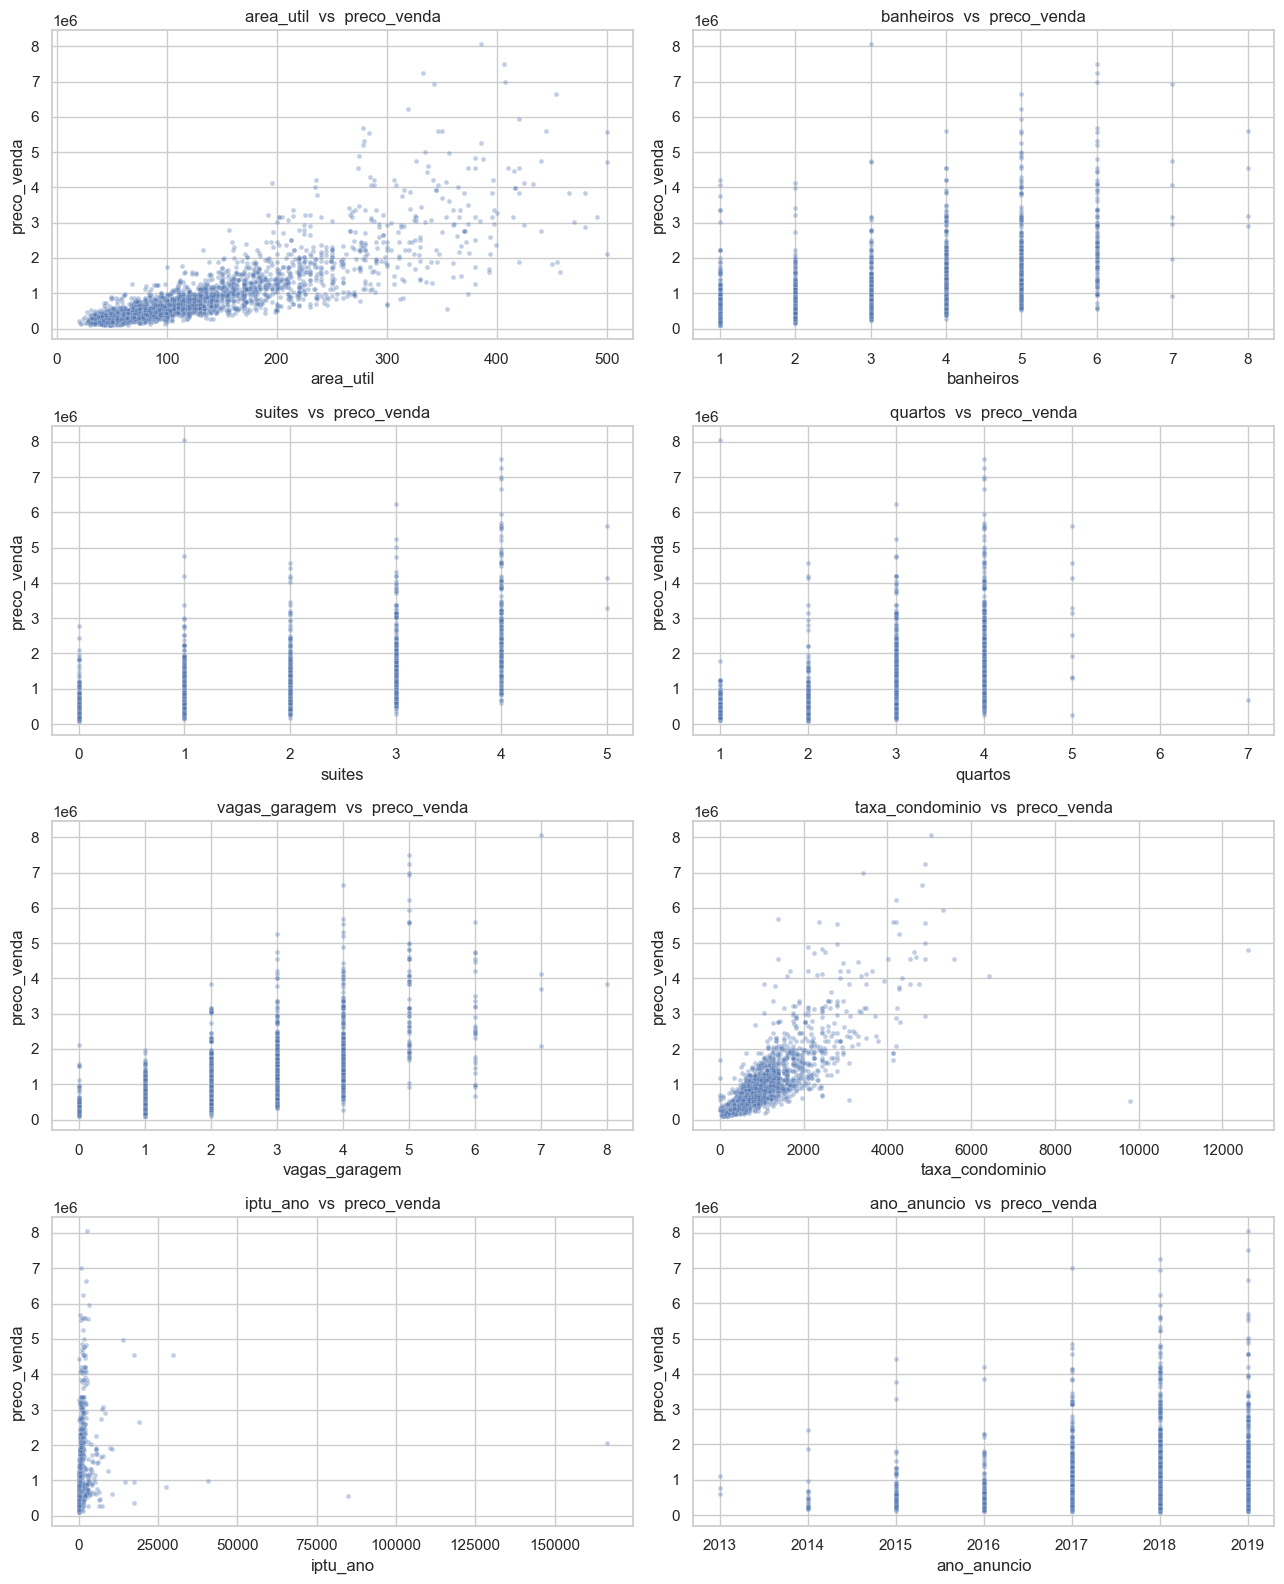

In [23]:
# scatter de cada feature vs preço (amostra de 4000 pontos p/ o gráfico não ficar pesado)
amostra = dados.sample(min(4000, len(dados)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for ax, col in zip(axes.ravel(), num_cols):
    sns.scatterplot(data=amostra, x=col, y="preco_venda", s=12, alpha=.35, ax=ax)
    ax.set_title(f"{col}  vs  preco_venda")
plt.tight_layout(); plt.show()

Repare que o `scatter` de `preco_venda` cru costuma mostrar um "funil" (variância
cresce com o preço). Isso é *heterocedasticidade* — mais um motivo para modelar em
`log1p`: no log o funil quase some.

> Seleção de features *por correlação com o alvo* é decisão que "olha o alvo" —
> se for fazer, faça no treino, depois do split. Aqui é só para **entender**.

## 13. EDA da variável categórica — `bairro`

Localização é o preditor mais forte de preço de imóvel. Mas `bairro` tem
**cardinalidade altíssima** (mais de mil valores), com uma cauda enorme de bairros
que aparecem só 1–2 vezes.

- Fazer *one-hot* de tudo criaria mais de mil colunas, muitas com pouquíssimos
  exemplos → *overfitting* e matriz gigante.
- **Solução padrão:** agrupar os bairros raros numa categoria `"Outros"`. O
  `OneHotEncoder` do scikit-learn faz isso sozinho com `min_frequency=` — e,
  colocado dentro da `Pipeline`, o "quem é raro" é decidido **só com o treino**.

bairros distintos: 1178
aparecem < 30 vezes: 907  (somam 5225 linhas, 8.6% da base)


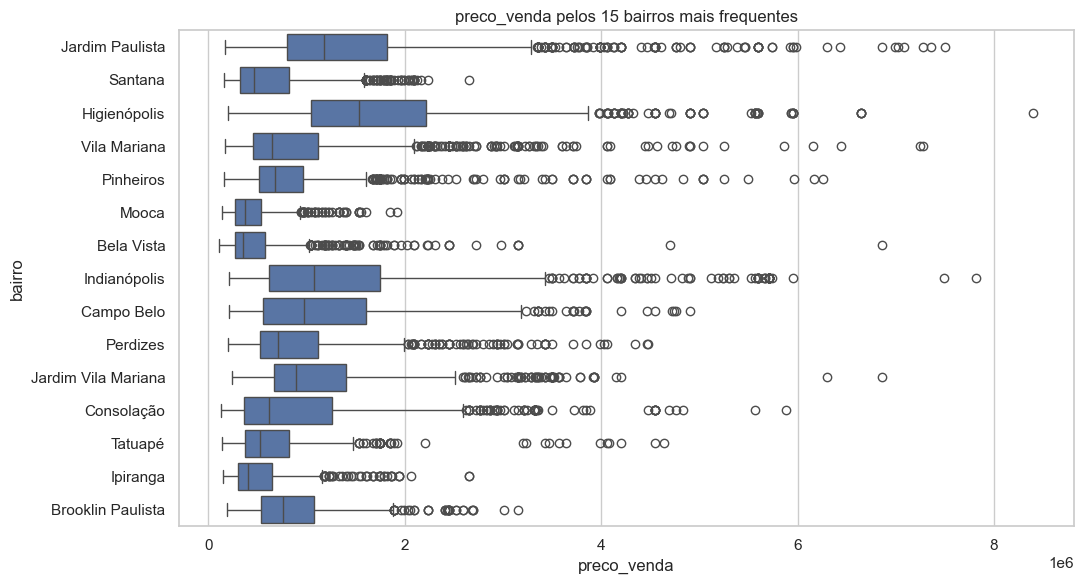

In [24]:
vc = dados["bairro"].value_counts()
print(f"bairros distintos: {dados['bairro'].nunique()}")
print(f"aparecem < 30 vezes: {(vc < 30).sum()}  "
      f"(somam {vc[vc < 30].sum()} linhas, {vc[vc < 30].sum()/len(dados):.1%} da base)")

top = vc.head(15).index
plt.figure(figsize=(11, 6))
sns.boxplot(data=dados[dados["bairro"].isin(top)],
            x="preco_venda", y="bairro", order=top)
plt.title("preco_venda pelos 15 bairros mais frequentes")
plt.tight_layout(); plt.show()

## 14. Split treino / teste

**Agora**, e não antes: tudo que fizemos até aqui foi ou objetivo, ou apenas
*olhar*. Nada aprendeu parâmetro dos dados.

Decisões:

- **80 / 20.** Com ~60 mil linhas, 20% ≈ 12 mil no teste — mais que suficiente para
  uma métrica estável. (Base pequena, < 2 mil linhas? Use *k-fold* em vez de um
  único split.)
- **`random_state` fixo** → o split é sempre o mesmo.
- **`stratify` numa faixa de preço** (`pd.qcut` em 10 faixas): garante que treino e
  teste tenham a mesma distribuição de preço. Sem isso, um sorteio azarado pode
  concentrar os imóveis caros de um lado só.
- **Alternativa:** se o modelo fosse usado para prever anúncios *futuros*, o certo
  seria **split temporal** (treinar com `ano_anuncio <= 2018`, testar em 2019).
  Aqui ficamos no split aleatório estratificado.

In [25]:
X = dados.drop(columns=["preco_venda"])
y = np.log1p(dados["preco_venda"])          # modelamos em log; volta com expm1

faixa_preco = pd.qcut(dados["preco_venda"], q=10, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=faixa_preco,
)
print("treino:", X_train.shape, " | teste:", X_test.shape)

treino: (48849, 11)  | teste: (12213, 11)


## 15. Pré-processamento **sem *leakage*** — `Pipeline` + `ColumnTransformer`

Tudo que **aprende** algo (mediana para imputar, média/desvio para escalar, quais
bairros são raros) fica aqui dentro. O `.fit()` roda **só no `X_train`**; o teste
só recebe `.transform()`. A validação cruzada re-ajusta a cada *fold* — impossível
vazar.

- **numéricas** → imputar mediana + padronizar (`StandardScaler`)
- **flags 0/1** → passam direto
- **`bairro`** → `OneHotEncoder(min_frequency=30, handle_unknown="ignore")`
  (agrupa raros e não quebra se aparecer bairro novo no teste)

In [26]:
col_num  = ["area_util", "banheiros", "suites", "quartos", "vagas_garagem",
            "taxa_condominio", "iptu_ano", "ano_anuncio"]
col_flag = ["taxa_condominio_sem_info", "iptu_ano_sem_info"]
col_cat  = ["bairro"]

prep = ColumnTransformer([
    ("num", Pipeline([("imput", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), col_num),
    ("flag", "passthrough", col_flag),
    ("cat", Pipeline([("imput", SimpleImputer(strategy="constant", fill_value="Desconhecido")),
                      ("ohe", OneHotEncoder(min_frequency=30, handle_unknown="ignore"))]), col_cat),
])

modelo = Pipeline([("prep", prep), ("reg", LinearRegression())])
modelo

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imput',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['area_util', 'banheiros',
                                                   'suites', 'quartos',
                                                   'vagas_garagem',
                                                   'taxa_condominio',
                                                   'iptu_ano', 'ano_anuncio']),
                                                 ('flag', 'passthrough',
                                                  ['taxa_condominio_sem_info',
                                                   'iptu_ano_sem_info']),
                                                 ('cat',
                                                  Pipeline(steps=[('imput',
                                                                   SimpleImputer(fill_value='Desconhecido',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=30))]),
                                                  ['bairro'])])),
                ('reg', LinearRegression())])

## 16. Baseline — regressão linear + validação cruzada

- Validação cruzada **dentro do treino** (5 *folds*) para estimar o desempenho sem
  tocar no teste.
- Métrica em `log` (RMSE do log) **e** de volta em reais (RMSE / MAE em R$), que é
  o que se explica para uma pessoa de negócio.
- O teste é avaliado **uma única vez**, no fim.

In [27]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rmse_log_cv = -cross_val_score(modelo, X_train, y_train, cv=cv,
                               scoring="neg_root_mean_squared_error")
print(f"RMSE(log)  CV: {rmse_log_cv.mean():.4f}  ± {rmse_log_cv.std():.4f}")

# --- ajuste final no treino inteiro e avaliação única no teste ---
modelo.fit(X_train, y_train)
pred_log = modelo.predict(X_test)

pred = np.expm1(pred_log)                 # volta para reais
real = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(real, pred))
mae  = mean_absolute_error(real, pred)
r2   = r2_score(y_test, pred_log)         # R² no espaço em que o modelo treinou

print(f"\nTESTE (avaliação única):")
print(f"  R² (log)   : {r2:.3f}")
print(f"  RMSE (R$)  : {rmse:,.0f}")
print(f"  MAE  (R$)  : {mae:,.0f}   (mediana ~ R$ {real.median():,.0f})")

# nota: o RMSE em R$ fica MUITO inflado porque expm1() amplia os poucos erros
# grandes da cauda de luxo. Para um baseline honesto, olhe o R²(log) e o MAE
# (mediana dos erros). A seção 17 traduz tudo isso em "acertou/errou quanto".

RMSE(log)  CV: 0.2586  ± 0.0036



TESTE (avaliação única):
  R² (log)   : 0.899
  RMSE (R$)  : 357,803
  MAE  (R$)  : 155,159   (mediana ~ R$ 458,500)


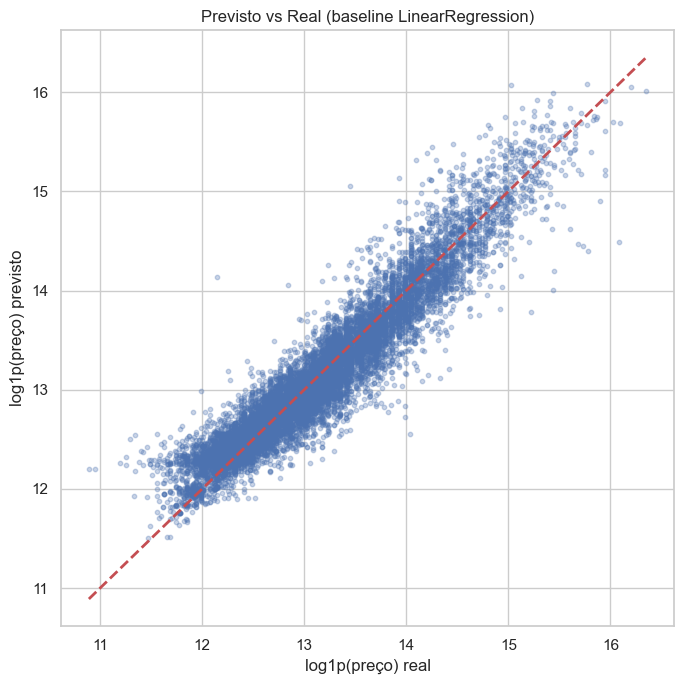

In [28]:
# Previsto vs Real (no espaço log) — pontos perto da diagonal = bom
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_log, s=10, alpha=.3)
lims = [min(y_test.min(), pred_log.min()), max(y_test.max(), pred_log.max())]
plt.plot(lims, lims, "r--", lw=2)
plt.xlabel("log1p(preço) real"); plt.ylabel("log1p(preço) previsto")
plt.title("Previsto vs Real (baseline LinearRegression)")
plt.tight_layout(); plt.show()

## 17. O modelo acertou ou errou? — explicado do zero

As métricas da seção 16 (`RMSE`, `R²`) não dizem nada para a intuição. Aqui a gente
olha do jeito mais concreto possível: **imóvel por imóvel, preço real × preço que o
modelo chutou.**

In [29]:
# Monta uma tabela: para cada imóvel do TESTE (que o modelo nunca viu),
# o preço real do anúncio  vs  o preço que o modelo previu.
comparacao = pd.DataFrame({
    "bairro":         X_test["bairro"].values,
    "area_util":      X_test["area_util"].values,
    "quartos":        X_test["quartos"].values,
    "preco_real":     real.values,
    "preco_previsto": pred.round(-3),                       # arredonda p/ milhar
})
comparacao["erro_reais"] = (comparacao["preco_previsto"] - comparacao["preco_real"]).round(-3)
comparacao["erro_%"]     = ((comparacao["preco_previsto"] - comparacao["preco_real"])
                            / comparacao["preco_real"] * 100).round(1)

print("15 imóveis quaisquer do conjunto de teste:")
comparacao.sample(15, random_state=1)

15 imóveis quaisquer do conjunto de teste:


,bairro,area_util,quartos,preco_real,preco_previsto,erro_reais,erro_%
4194,Vila Cordeiro,121.0,3.0,945699.0,801000.0,-145000.0,-15.3
6313,Santana,186.0,3.0,944999.0,725000.0,-220000.0,-23.3
4061,Bosque da Saúde,65.0,2.0,349300.0,442000.0,93000.0,26.5
3259,Campo Belo,160.0,4.0,979999.0,993000.0,13000.0,1.3
1475,Chora Menino,52.0,2.0,273504.0,275000.0,1000.0,0.5
12207,Vila da Saúde,85.0,3.0,535500.0,508000.0,-28000.0,-5.1
825,Santana,123.0,3.0,805000.0,526000.0,-279000.0,-34.7
396,Jardim Vila Mariana,100.0,3.0,595000.0,627000.0,32000.0,5.4
11306,Consolação,77.0,1.0,380800.0,443000.0,62000.0,16.3
3304,Vila Gumercindo,103.0,3.0,714000.0,540000.0,-174000.0,-24.4


Como ler a linha: *"apê de 48 m², 2 quartos no Sacomã. Preço real do anúncio:
R\$ 230 mil. O modelo, olhando só área/quartos/bairro/etc., chutou R\$ 235 mil.
Errou R\$ 5 mil, ou seja **+2%**."* Erro positivo = o modelo **superestimou**;
negativo = **subestimou**.

In [30]:
# Onde o modelo mais ACERTOU e onde mais ERROU
menor = comparacao.reindex(comparacao["erro_%"].abs().sort_values().index)
print("=== 5 melhores previsões ===")
print(menor.head(5).to_string(index=False))
print("\n=== 5 piores previsões ===")
print(menor.tail(5).to_string(index=False))

=== 5 melhores previsões ===
              bairro  area_util  quartos  preco_real  preco_previsto  erro_reais  erro_%
       Jardim Textil       65.0      2.0    258999.0        259000.0         0.0     0.0
        Vila Formosa       81.0      3.0    392000.0        392000.0         0.0     0.0
             Cambuci       38.0      2.0    273000.0        273000.0         0.0     0.0
               Limão       63.0      3.0    266000.0        266000.0         0.0     0.0
Vila Pereira Barreto       57.0      3.0    251999.0        252000.0         0.0     0.0

=== 5 piores previsões ===
          bairro  area_util  quartos  preco_real  preco_previsto  erro_reais  erro_%
  Vila Paulicéia      420.0      4.0   1323000.0       4476000.0   3153000.0   238.3
    Vila Popular       46.0      2.0     56994.0        199000.0    142000.0   249.2
    Jardim Célia       45.0      2.0     53690.0        198000.0    144000.0   268.8
    Vila Andrade      450.0      4.0    693000.0       3447000.0   27

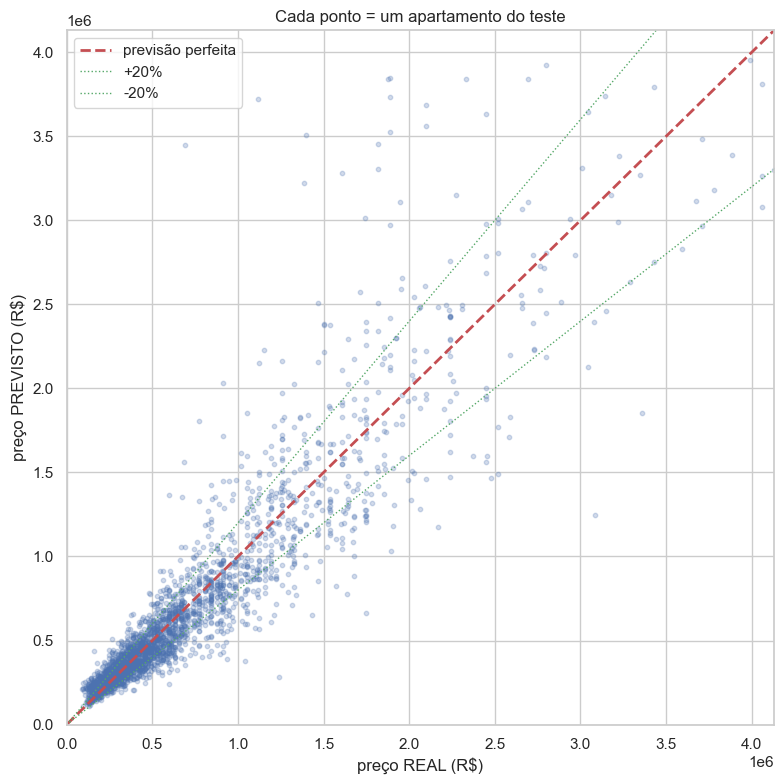

In [31]:
# O mesmo, em gráfico. Cada ponto é um imóvel.
# Eixo X = preço real   |   Eixo Y = preço previsto
# Linha tracejada = "previsão perfeita" (previsto == real).
# Ponto ACIMA da linha = modelo cobrou caro demais;  ABAIXO = barato demais.
amostra_g = comparacao.sample(3000, random_state=RANDOM_STATE)

plt.figure(figsize=(8, 8))
plt.scatter(amostra_g["preco_real"], amostra_g["preco_previsto"], s=10, alpha=.25)
lim = [0, comparacao["preco_real"].quantile(.99)]
plt.plot(lim, lim, "r--", lw=2, label="previsão perfeita")
plt.plot(lim, [1.2*lim[0], 1.2*lim[1]], "g:", lw=1, label="+20%")
plt.plot(lim, [0.8*lim[0], 0.8*lim[1]], "g:", lw=1, label="-20%")
plt.xlim(lim); plt.ylim(lim)
plt.xlabel("preço REAL (R$)"); plt.ylabel("preço PREVISTO (R$)")
plt.title("Cada ponto = um apartamento do teste")
plt.legend(); plt.tight_layout(); plt.show()

### O resumão, em português (números na saída da célula acima)

- **Erro típico (mediana ≈ 14%).** Metade dos apartamentos o modelo acerta com menos
  de ~14% de diferença. Num apê de R\$ 500 mil, isso é errar uns **R\$ 70 mil** para
  cima ou para baixo.
- **~2 em cada 3 apartamentos:** erro abaixo de 20%.
- **Às vezes erra muito** (veja "5 piores previsões" acima): normalmente são imóveis
  atípicos — muito baratos para o bairro, ou com área perto do limite que deixamos
  passar — que fogem da "regra média" que a reta aprendeu.

### E aqueles termos que assustam?

**Modelo burro (*baseline*).** Um "modelo" que ignora tudo — área, bairro, quartos —
e **sempre responde o preço médio** (~R\$ 760 mil para qualquer imóvel). Ele serve
de **régua do nível zero**: se o seu modelo não erra *bem menos* que o burro, ele não
aprendeu nada. (A célula abaixo mostra: o burro erra bem mais.) ✅

**R² (lê-se "R quadrado").** Uma **nota de 0 a 1** que resume isso num número só:
· `R² = 0` → tão ruim quanto o modelo burro
· `R² = 1` → acertou tudo na mosca
· o seu: **~0,90** → decente para um primeiro modelo linear.

**Overfitting ("decoreba").** Quando o modelo **decora** os imóveis que viu no treino
em vez de aprender a regra geral — vai bem na "aula" e mal na "prova". Você detecta
comparando o erro nos dados de treino com o erro nos dados de teste: se o `R²` do
treino e o do teste ficam **praticamente iguais** (é o caso aqui), o modelo **não**
decorou — aprendeu de verdade.

In [32]:
from sklearn.dummy import DummyRegressor

# 1) o "modelo burro": sempre chuta a média
burro = Pipeline([("prep", prep), ("reg", DummyRegressor(strategy="mean"))]).fit(X_train, y_train)
erro_burro  = -cross_val_score(burro,  X_train, y_train, cv=cv,
                               scoring="neg_root_mean_squared_error").mean()
erro_modelo = rmse_log_cv.mean()
print(f"RMSE(log)  modelo burro : {erro_burro:.3f}")
print(f"RMSE(log)  seu modelo   : {erro_modelo:.3f}   "
      f"-> erra {(1 - erro_modelo/erro_burro)*100:.0f}% menos que o burro")

# 2) decoreba? erro no treino vs no teste
print(f"\nR²  treino : {r2_score(y_train, modelo.predict(X_train)):.3f}")
print(f"R²  teste  : {r2_score(y_test,  pred_log):.3f}   (perto um do outro = sem overfitting)")

# 3) erro que dá pra sentir
ape = (comparacao['preco_previsto'] - comparacao['preco_real']).abs() / comparacao['preco_real']
print(f"\nerro % típico (mediana) : {ape.median()*100:.0f}%")
print(f"imóveis com erro < 20%  : {(ape < .20).mean()*100:.0f}%")

RMSE(log)  modelo burro : 0.790
RMSE(log)  seu modelo   : 0.259   -> erra 67% menos que o burro

R²  treino : 0.898
R²  teste  : 0.899   (perto um do outro = sem overfitting)

erro % típico (mediana) : 14%
imóveis com erro < 20%  : 64%


### Veredito do baseline

| Pergunta | Resposta | |
|---|---|---|
| Vence o modelo burro? | erra ~⅔ menos, `R²` ≈ 0,90 | ✅ aprendeu de verdade |
| Está decorando (overfitting)? | `R²` treino ≈ `R²` teste | ✅ não |
| Erra pouco o suficiente para uso real? | ~14% típico (± R\$ 70 mil num apê de R\$ 500 mil) | ⚠️ serve para estimativa, não para precificar de verdade |

**É um bom ponto de partida, não um produto final.** Melhorar isso (chegar a erro de
~8–10%) é o trabalho da seção 19.

## 18. Interpretação dos coeficientes — `statsmodels` (o "outro lado" da regressão)

Até aqui o foco foi **prever** (`sklearn`). Agora o outro uso da regressão linear:
**explicar** — dizer *qual* variável afeta o preço, *quanto*, e se esse efeito é
**estatisticamente confiável** (`p-valor`). É a tabela da seção 9 da nota
*Regressão Linear*.

Duas escolhas de propósito, diferentes do modelo `sklearn`:

- **Sem `bairro`.** Só as 8 numéricas + as 2 flags. Com `bairro` a tabela teria
  ~270 linhas (uma por bairro) e seria ilegível. `bairro` continua importante — é
  por isso que o `R²` aqui (~0,78) é menor que o do modelo completo (~0,90).
- **Escala crua (sem `StandardScaler`).** Assim o coeficiente volta a ter a leitura
  "unidades reais" da nota: *quanto o preço muda para cada +1 unidade da variável*.
  Como o alvo está em `log`, `exp(coef) − 1` ≈ **variação percentual no preço**.

In [33]:
import statsmodels.api as sm

col_sm = col_num + col_flag                       # sem bairro, de propósito

Xsm = X_train[col_sm].copy()
medianas_tr = Xsm[col_num].median()              # imputação: mediana do TREINO
Xsm[col_num] = Xsm[col_num].fillna(medianas_tr)

Xsm = sm.add_constant(Xsm)                        # adiciona o intercepto (o 'a' da nota)
ols = sm.OLS(y_train, Xsm).fit()                 # y_train já está em log1p
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:            preco_venda   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                 1.710e+04
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:26:06   Log-Likelihood:                -21050.
No. Observations:               48849   AIC:                         4.212e+04
Df Residuals:                   48838   BIC:                         4.222e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [34]:
# Mesma tabela, enxuta e traduzida para "efeito no preço"
resumo_coef = pd.DataFrame({
    "coef (em log)":  ols.params,
    "p-valor":        ols.pvalues,
    "significativo?": np.where(ols.pvalues < 0.05, "sim (p<0,05)", "NÃO"),
    "efeito ~ no preço por +1 unidade": ols.params.apply(lambda c: f"{np.expm1(c)*100:+.1f}%"),
}).drop(index="const").round(4)
resumo_coef

,coef (em log),p-valor,significativo?,efeito ~ no preço por +1 unidade
area_util,0.0053,0.0,"sim (p<0,05)",+0.5%
banheiros,0.0952,0.0,"sim (p<0,05)",+10.0%
suites,0.0892,0.0,"sim (p<0,05)",+9.3%
quartos,-0.0229,0.0,"sim (p<0,05)",-2.3%
vagas_garagem,0.0455,0.0,"sim (p<0,05)",+4.7%
taxa_condominio,0.0001,0.0,"sim (p<0,05)",+0.0%
iptu_ano,-0.0000,0.0,"sim (p<0,05)",-0.0%
ano_anuncio,0.0302,0.0,"sim (p<0,05)",+3.1%
taxa_condominio_sem_info,0.1127,0.0,"sim (p<0,05)",+11.9%
iptu_ano_sem_info,-0.1946,0.0,"sim (p<0,05)",-17.7%


### Como ler (ligando na nota)

- **`p-valor` < 0,05 → "a variável tem efeito real em Y"** (§9: `H₀: b = 0`).
  Aqui **todas** dão `p < 0,001`. Isso *não* quer dizer que todas importam muito —
  com ~49 mil linhas, quase qualquer efeito minúsculo vira "significativo".
  **Significância estatística ≠ importância prática.** Olhe o *tamanho* do efeito,
  não só o `p`.
- **Efeitos que fazem sentido:** cada **banheiro** ≈ +10% no preço, cada **suíte**
  ≈ +9%, cada **vaga** ≈ +5%, cada **m²** ≈ +0,5% (ou seja, +10 m² ≈ +5%).
- **`quartos` com efeito NEGATIVO (~−2%)?** É o *ceteris paribus* da nota (§7):
  *mantendo área, banheiros e suítes fixos*, picar o mesmo espaço em mais quartos
  (quartos menores) desvaloriza de leve. "Apês com mais quartos custam mais" é
  verdade — mas por causa da área, não do número de quartos em si.
- **`iptu_ano_sem_info` ≈ −18%:** imóvel sem IPTU informado tende a ser mais barato
  (a flag da seção 11 capturou um sinal real).
- No rodapé do `summary()`: **`Cond. No.` gigante** = aviso de **multicolinearidade**
  (nota §12 / seção 12 deste notebook) — os coeficientes individuais ficam menos
  confiáveis. E **`Prob(JB) = 0`** = resíduos não perfeitamente normais (§8) — com
  `n` grande o `t`/`p` aguentam, mas é bom saber.

> `sklearn` para **prever**, `statsmodels` para **entender**. Mesmo OLS por baixo —
> a nota já dizia que os dois chegam ao mesmo `a` e `b`.

## 19. Resumo — o "padrão-ouro" em uma tela

1. **Alvo primeiro.** Tipo de problema, métrica, transformação (`log` se assimétrico).
2. **Escopo antes do split.** Escolha um mercado; o modelo representa só ele.
3. **Três problemas distintos:** impossível (remove antes) · faltante (imputa na
   pipeline, no treino) · extremo real (só apara o treino, se aparar).
4. **Filtro com comparação apaga `NaN` sem avisar.** Sempre `... | serie.isna()`.
5. **Uma célula idempotente** para remover linhas; inspeção em célula separada.
6. **EDA = gráficos**, não só `describe`: histograma, boxplot, scatter, heatmap.
7. **Multicolinearidade** entre features numéricas → coeficientes não confiáveis.
8. **Split:** 80/20, `random_state`, `stratify` em faixa do alvo (ou split temporal).
9. **Tudo que aprende parâmetro vive na `Pipeline`** e faz `fit` só no treino.
10. **Cross-validation no treino** para decidir; **teste uma vez só**, no fim.

### Próximos passos (por sua conta)
- Comparar com `Ridge` / `Lasso` (lidam melhor com multicolinearidade).
- Analisar resíduos (vs previsão, vs cada feature) para achar padrão que falta.
- Testar `preco_por_m2`, interação `area × bairro`, `log` em `area_util`.
- Revisitar os cortes de "impossível": eles estão conservadores de propósito.